# Autoencoder for Image Denoising (MNIST)
Goal: Build a deep learning autoencoder that removes noise from handwritten digit images (MNIST dataset).

#  Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## Load and preprocess MNIST

In [2]:
(x_train,_),(x_test,_) = mnist.load_data()

x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0

x_train = np.expand_dims(x_train,-1)
x_test = np.expand_dims(x_test,-1)

print(x_train.shape,x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(60000, 28, 28, 1) (10000, 28, 28, 1)


## Add Gaussian Noise

In [3]:
noise_factor=0.4

def add_noise(images,factor=noise_factor):
    noisy = images + factor*np.random.normal(size=images.shape)
    return np.clip(noisy,0.,1.)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)


## Display Original and Noisy Images

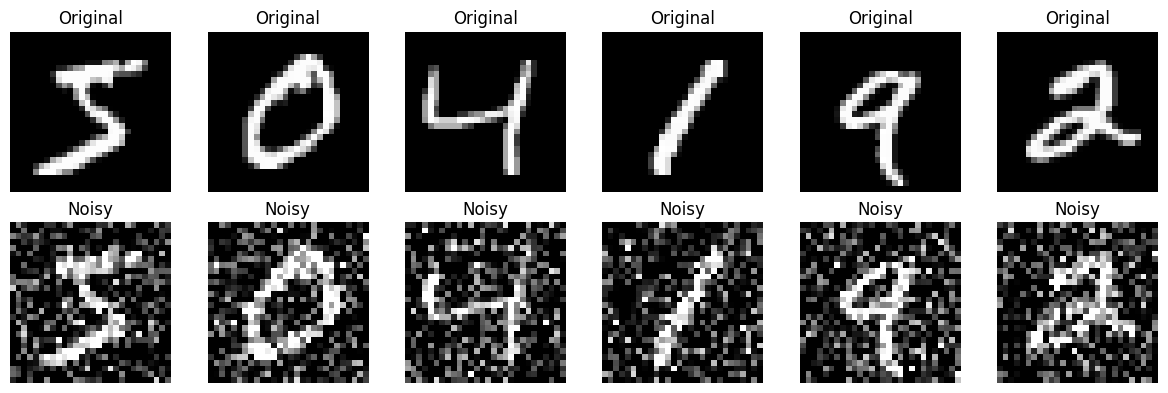

In [4]:
plt.figure(figsize=(12,4))
for i in range(6):
    plt.subplot(2,6,i+1)
    plt.imshow(x_train[i].squeeze(),cmap="gray")
    plt.axis("off")
    plt.title("Original")
    plt.subplot(2,6,i+7)
    plt.imshow(x_train_noisy[i].squeeze(),cmap="gray")
    plt.axis("off")
    plt.title("Noisy")
plt.tight_layout()
plt.show()


## Build CNN Autoencoder
Encoder: Conv2D + MaxPooling layers progressively compress the 28x28 image into a smaller latent representation.

Decoder: Conv2D + UpSampling layers reconstruct the 28x28 image back from the compressed representation.

The final layer uses a sigmoid activation since pixel values are normalized between 0 and 1.

In [5]:
inputs=keras.Input(shape=(28,28,1))

# Encoder
x=layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x=layers.MaxPooling2D(2,padding='same')(x)
x=layers.Conv2D(16,3,activation='relu',padding='same')(x)
encoded=layers.MaxPooling2D(2,padding='same')(x)

# Decoder
x=layers.Conv2D(16,3,activation='relu',padding='same')(encoded)
x=layers.UpSampling2D(2)(x)
x=layers.Conv2D(32,3,activation='relu',padding='same')(x)
x=layers.UpSampling2D(2)(x)
outputs=layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

autoencoder=keras.Model(inputs,outputs)
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Model (MSE Loss)

In [6]:
autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mse']
)


## Train Model

In [7]:
history=autoencoder.fit(
    x_train_noisy,
    x_train,
    validation_data=(x_test_noisy,x_test),
    epochs=20,
    batch_size=128,
    shuffle=True
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - loss: 0.1141 - mse: 0.1141 - val_loss: 0.1140 - val_mse: 0.1140
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.1120 - mse: 0.1120 - val_loss: 0.1140 - val_mse: 0.1140
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.1120 - mse: 0.1120 - val_loss: 0.1140 - val_mse: 0.1140
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 0.1120 - mse: 0.1120 - val_loss: 0.1140 - val_mse: 0.1140
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.1120 - mse: 0.1120 - val_loss: 0.1140 - val_mse: 0.1140
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.1120 - mse: 0.1120 - val_loss: 0.1140 - val_mse: 0.1140
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.1120 - mse: 0.1120 - val_loss: 0.1140 - val_mse: 0.1140
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.1120 - mse: 0.1120 - val_loss: 0.1140 - val_mse: 0.1140
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 

## Plot Training History

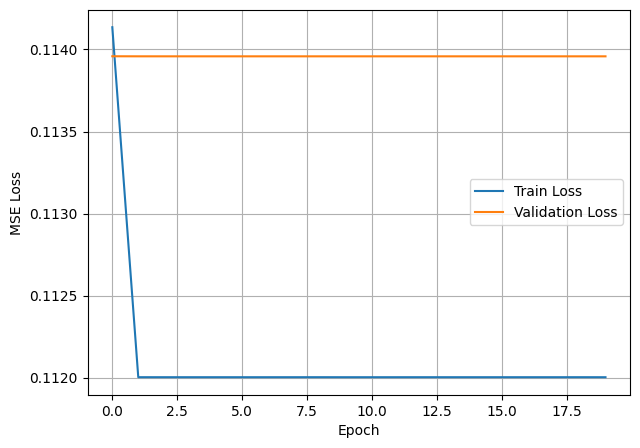

In [11]:
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


## Reconstruct Images

In [9]:
denoised=autoencoder.predict(x_test_noisy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


## Visual Comparison
Compare the original clean image, the noisy input, and the denoised output produced by the autoencoder.

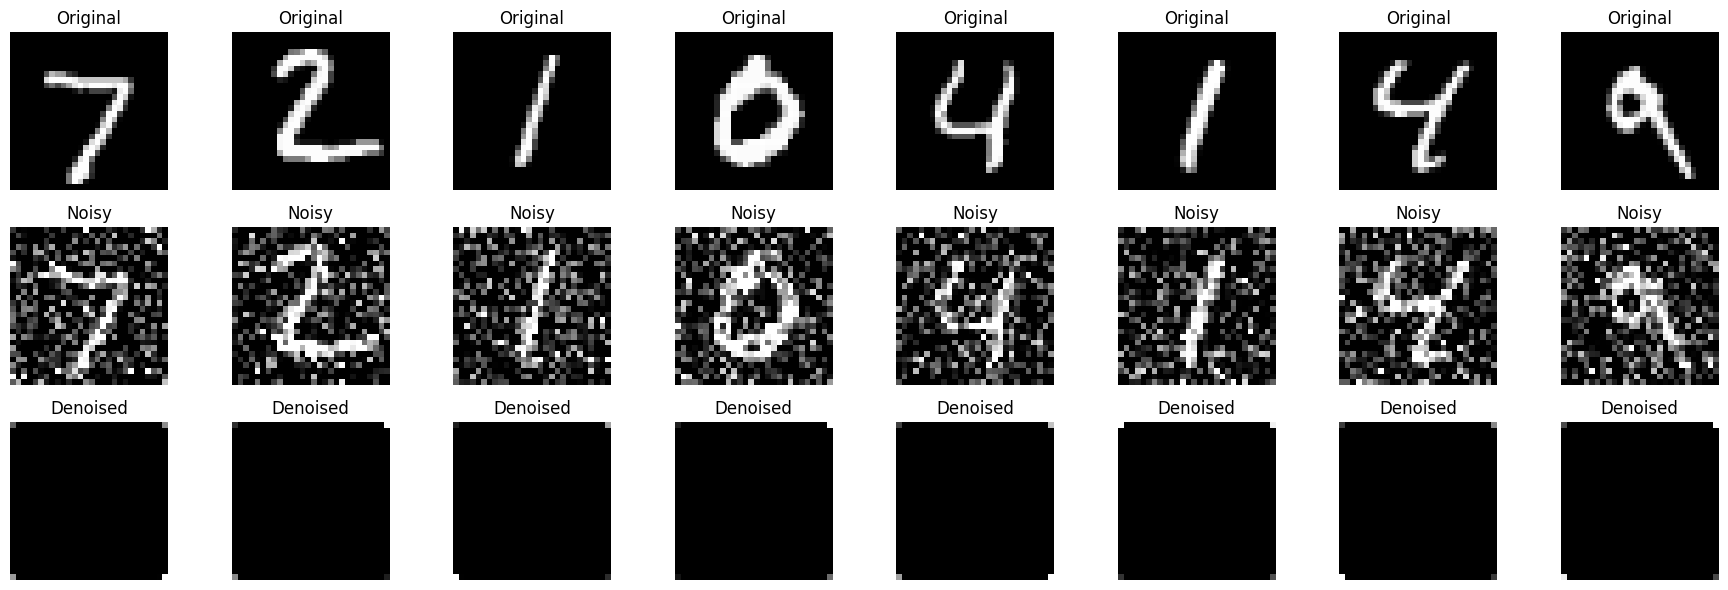

In [12]:
n=8
plt.figure(figsize=(18,6))
for i in range(n):
    plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].squeeze(),cmap='gray')
    plt.axis('off')
    plt.title("Original")

    plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].squeeze(),cmap='gray')
    plt.axis('off')
    plt.title("Noisy")

    plt.subplot(3,n,i+2*n+1)
    plt.imshow(denoised[i].squeeze(),cmap='gray')
    plt.axis('off')
    plt.title("Denoised")
plt.tight_layout()
plt.show()


## Evaluate using MSE and PSNR

In [13]:
test_mse = np.mean((x_test-denoised)**2)
print("Test MSE:",test_mse)

def psnr(original,reconstructed):
    mse=np.mean((original-reconstructed)**2)
    return 20*np.log10(1.0/np.sqrt(mse))

print("PSNR (Noisy):",psnr(x_test,x_test_noisy))
print("PSNR (Denoised):",psnr(x_test,denoised))


Test MSE: 0.1139581
PSNR (Noisy): 10.990019251711887
PSNR (Denoised): 9.4325485


## Predict Single Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


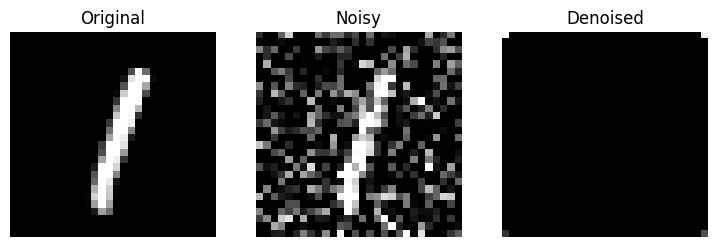

In [14]:
idx=5
pred=autoencoder.predict(x_test_noisy[idx:idx+1])

plt.figure(figsize=(9,3))
titles=['Original','Noisy','Denoised']
imgs=[x_test[idx],x_test_noisy[idx],pred[0]]
for i,img in enumerate(imgs):
    plt.subplot(1,3,i+1)
    plt.imshow(img.squeeze(),cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()


# Conclusion

- Loaded and normalized MNIST.
- Added Gaussian noise.
- Built a convolutional denoising autoencoder.
- Trained using Adam optimizer and Mean Squared Error (MSE) loss.
- Evaluated reconstruction using MSE and PSNR.
- Successfully reconstructed clean images from noisy inputs.
